# A6 domain time-course simulation — v6

This version separates the observed data from the simulated trajectory.

\[
\text{observed A6}
\quad\text{vs}\quad
\text{simulated }t=0
\rightarrow
\text{simulated }t=0.5
\rightarrow
\text{simulated }t=1.
\]

- The observed column uses `STAIR`, `cell_type`, and observed Nnat counts.
- Simulated region labels at \(t=0\) are the domain-model predictions stored in `pred_region`.
- The \(t=0.5\) and \(t=1\) regions are deformations of the simulated \(t=0\) regions.
- At every simulated time point, cell-type probabilities and labels are generated from that time point's simulated regions.
- Gene-expression means and NB counts are then generated from the simulated region and cell-type labels.
- Template-transported coordinates use the saved training PCA; PCA is never refitted.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import pickle
import joblib

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors


# ---------------- files ----------------
ADATA_PATH = Path("../adata_backup_with_pred_region_celltype.h5ad")
GENE_FITS_PATH = Path("../saved_models/gene_fit_results_A6.pkl")
CELLTYPE_MODEL_PATH = Path("../saved_models/celltype_mlp_state.pt")
CELLTYPE_PREPROCESS_PATH = Path("../saved_models/celltype_preprocess.joblib")

OUT_DIR = Path("A6_domain_timecourse_v6")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------- user inputs ----------------
SLICE_ID = "A6"

# Observed annotations used only in the leftmost comparison column.
REAL_REGION_KEY = "STAIR"
REAL_CELLTYPE_KEY = "cell_type"

# Model-generated labels used to initialize the simulation.
SIM_REGION_KEY = "pred_region"

ACTIVE_REGION = "12.0"
COLLISION_REGION = "13.0"
EXPECTED_CELLTYPE = "Ependymal"
PLOT_GENE = "Nnat"

TIMES = np.array([0.0, 0.5, 1.0])

# Final active-region area = (1 + FINAL_AREA_GROWTH) × t=0 simulated area.
FINAL_AREA_GROWTH = 2.00
MOVE_DIRECTION = f"toward:{COLLISION_REGION}"
MOVE_DISTANCE = 0.15

BATCH_KEY = "batch"

GENE_SEED = 20260622
CELLTYPE_SEED = 20260623


@dataclass(frozen=True)
class RegionAction:
    region: str
    final_area_growth: float
    direction: object
    move_distance: float


REGION_ACTIONS = [
    RegionAction(
        region=ACTIVE_REGION,
        final_area_growth=FINAL_AREA_GROWTH,
        direction=MOVE_DIRECTION,
        move_distance=MOVE_DISTANCE,
    )
]

In [2]:
# ---------- fixed-boundary domain evolution ----------
def smoothstep(t):
    t = np.clip(float(t), 0.0, 1.0)
    return 3.0 * t**2 - 2.0 * t**3


def sorted_labels(values):
    def key(x):
        try:
            return (0, float(x))
        except (TypeError, ValueError):
            return (1, str(x))
    return sorted(map(str, values), key=key)


def local_area_weights(xy, k=6):
    k = min(max(3, k), len(xy))
    d = NearestNeighbors(n_neighbors=k).fit(xy).kneighbors(
        xy, return_distance=True
    )[0][:, -1]
    return np.maximum(d, 1e-10) ** 2


def signed_distance_fields(xy, labels, levels):
    fields = np.empty((len(xy), len(levels)))

    for j, region in enumerate(levels):
        inside = labels == region
        outside = ~inside

        d_inside = NearestNeighbors(n_neighbors=1).fit(
            xy[inside]
        ).kneighbors(xy, return_distance=True)[0][:, 0]

        d_outside = NearestNeighbors(n_neighbors=1).fit(
            xy[outside]
        ).kneighbors(xy, return_distance=True)[0][:, 0]

        fields[:, j] = d_outside - d_inside

    return fields


def direction_vector(spec, region, centers):
    if spec is None:
        return np.zeros(2)

    if isinstance(spec, str):
        cardinal = {
            "left": np.array([-1.0, 0.0]),
            "right": np.array([1.0, 0.0]),
            "up": np.array([0.0, -1.0]),
            "down": np.array([0.0, 1.0]),
        }

        if spec in cardinal:
            vector = cardinal[spec]
        elif spec.startswith("toward:"):
            target = spec.split(":", 1)[1]
            vector = centers[target] - centers[region]
        elif spec.startswith("away:"):
            target = spec.split(":", 1)[1]
            vector = centers[region] - centers[target]
        else:
            raise ValueError(f"Unsupported direction: {spec}")
    else:
        vector = np.asarray(spec, dtype=float)

    return vector / max(np.linalg.norm(vector), 1e-12)


def interpolate_field(model, query, field):
    distance, index = model.kneighbors(
        query, return_distance=True
    )
    weight = 1.0 / np.maximum(distance, 1e-10) ** 2
    weight /= weight.sum(axis=1, keepdims=True)
    return np.sum(weight * field[index], axis=1)


def action_state(action, t, xy, centers):
    g = smoothstep(t)
    area_multiplier = 1.0 + action.final_area_growth * g
    spatial_scale = np.sqrt(area_multiplier)
    tissue_scale = min(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]))

    shift = (
        g
        * action.move_distance
        * tissue_scale
        * direction_vector(
            action.direction,
            str(action.region),
            centers,
        )
    )

    return {
        "center": centers[str(action.region)].copy(),
        "scale": float(spatial_scale),
        "shift": np.asarray(shift, dtype=float),
        "area_multiplier": float(area_multiplier),
    }


def inverse_transport_xy(xy_current, state):
    center = state["center"]
    return (
        center
        + (
            xy_current
            - (center + state["shift"])
        )
        / state["scale"]
    )


def generate_domain_trajectory(
    xy,
    baseline_labels,
    actions,
    times,
    weights,
):
    baseline_labels = np.asarray(baseline_labels).astype(str)
    levels = sorted_labels(pd.unique(baseline_labels))
    level_index = {region: j for j, region in enumerate(levels)}

    centers = {
        region: xy[baseline_labels == region].mean(axis=0)
        for region in levels
    }
    baseline_area = {
        region: weights[baseline_labels == region].sum()
        for region in levels
    }

    base_fields = signed_distance_fields(
        xy, baseline_labels, levels
    )
    interpolator = NearestNeighbors(
        n_neighbors=min(12, len(xy))
    ).fit(xy)

    labels_by_time = []
    transports_by_time = []

    for t in times:
        transport_t = {
            str(action.region): action_state(
                action, t, xy, centers
            )
            for action in actions
        }
        transports_by_time.append(transport_t)

        if np.isclose(t, 0.0):
            labels_by_time.append(baseline_labels.copy())
            continue

        scores = base_fields.copy()
        target_areas = {}

        for action in actions:
            region = str(action.region)
            j = level_index[region]
            state = transport_t[region]

            template_xy = inverse_transport_xy(xy, state)
            scores[:, j] = interpolate_field(
                interpolator,
                template_xy,
                base_fields[:, j],
            )
            target_areas[region] = (
                baseline_area[region]
                * state["area_multiplier"]
            )

        biases = np.zeros(len(levels))

        for _ in range(8):
            for region, target_area in target_areas.items():
                j = level_index[region]
                adjusted = scores + biases[None, :]
                other = np.delete(adjusted, j, axis=1).max(axis=1)
                margin = other - scores[:, j]

                lo, hi = margin.min(), margin.max()
                for _ in range(45):
                    mid = 0.5 * (lo + hi)
                    won_area = weights[margin <= mid].sum()
                    if won_area < target_area:
                        lo = mid
                    else:
                        hi = mid

                biases[j] = 0.5 * (lo + hi)

        labels_t = np.asarray(levels)[
            np.argmax(scores + biases[None, :], axis=1)
        ]
        labels_by_time.append(labels_t)

    return (
        labels_by_time,
        transports_by_time,
        levels,
    )

In [3]:
# ---------- saved PCA template coordinates and cell-type model ----------
class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, n_celltypes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)


def load_celltype_model():
    prep = joblib.load(CELLTYPE_PREPROCESS_PATH)

    prep["region_categories"] = list(
        map(str, prep["region_categories"])
    )
    prep["celltype_names"] = [
        str(name).replace("prob_", "")
        for name in prep["prob_cols"]
    ]
    prep["reference_transforms"] = {
        str(region): transform
        for region, transform in prep[
            "region_coordinate_transforms"
        ].items()
    }

    model = SpatialProbMLP(
        int(prep["input_dim"]),
        int(prep["n_celltypes"]),
    )

    try:
        state = torch.load(
            CELLTYPE_MODEL_PATH,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        state = torch.load(
            CELLTYPE_MODEL_PATH,
            map_location="cpu",
        )

    model.load_state_dict(state)
    model.eval()
    return model, prep


def transported_celltype_features(
    coords_3d,
    current_regions,
    transport_t,
    prep,
):
    """
    Map current cells back to each region's baseline template,
    then apply the PCA and scaling saved during model training.
    """
    coords_3d = np.asarray(coords_3d, dtype=float)
    current_regions = np.asarray(current_regions).astype(str)

    categories = prep["region_categories"]
    category_index = {
        region: j for j, region in enumerate(categories)
    }
    transforms = prep["reference_transforms"]

    relative = np.zeros((len(coords_3d), 3), dtype=float)

    for region in np.unique(current_regions):
        if region not in transforms:
            raise KeyError(
                f"No saved PCA transform for region {region}."
            )

        mask = current_regions == region
        template_xyz = coords_3d[mask].copy()

        # Active regions are mapped back by the exact inverse deformation.
        # Regions without an action use the identity map.
        if region in transport_t:
            template_xyz[:, :2] = inverse_transport_xy(
                template_xyz[:, :2],
                transport_t[region],
            )

        transform = transforms[region]
        pca = transform["pca"]

        if pca is None:
            projected = template_xyz
        else:
            projected = pca.transform(template_xyz)

        minimum = np.asarray(
            transform["min_xyz"], dtype=float
        )
        span = np.asarray(
            transform["scale"], dtype=float
        )
        span = np.where(span < 1e-6, 1.0, span)

        relative[mask] = np.clip(
            2.0 * (projected - minimum) / span - 1.0,
            -1.0,
            1.0,
        )

    onehot = np.zeros(
        (len(coords_3d), len(categories)),
        dtype=float,
    )
    for i, region in enumerate(current_regions):
        onehot[i, category_index[region]] = 1.0

    features = np.c_[relative, onehot]

    if features.shape[1] != int(prep["input_dim"]):
        raise ValueError(
            "Cell-type feature dimension does not match "
            "the saved model."
        )

    return features, relative


def sample_celltypes_with_uniforms(
    probabilities,
    names,
    uniforms,
):
    """
    Use the same cell-specific uniforms at all time points.

    If a cell's probability vector does not change, its sampled cell type
    also does not change. This removes unnecessary Monte Carlo differences
    between time points.
    """
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities /= np.maximum(
        probabilities.sum(axis=1, keepdims=True),
        1e-12,
    )

    cumulative = np.cumsum(probabilities, axis=1)
    index = (
        uniforms[:, None] > cumulative
    ).sum(axis=1)
    index = np.minimum(index, len(names) - 1)
    return np.asarray(names)[index]

In [4]:
# ---------- observed data and simulated region trajectory ----------
adata = sc.read(ADATA_PATH)

with open(GENE_FITS_PATH, "rb") as handle:
    gene_bundle = pickle.load(handle)

celltype_model, celltype_prep = load_celltype_model()

a6 = adata[
    adata.obs[BATCH_KEY].astype(str) == SLICE_ID
].copy()

# The saved gene design fixes the A6 cell order.
saved_obs = list(map(str, gene_bundle["obs_names"]))
if set(saved_obs) != set(map(str, a6.obs_names)):
    raise ValueError(
        "The saved gene model and the current A6 object "
        "do not contain exactly the same cells."
    )
a6 = a6[saved_obs].copy()

for key in (
    REAL_REGION_KEY,
    REAL_CELLTYPE_KEY,
    SIM_REGION_KEY,
):
    if key not in a6.obs:
        raise KeyError(f"Missing a6.obs[{key!r}].")

spatial_key = str(celltype_prep["spatial_key"])
coords_3d = np.asarray(
    a6.obsm[spatial_key][:, :3],
    dtype=float,
)
xy = coords_3d[:, :2]

# Leftmost observed-data column.
real_regions = (
    a6.obs[REAL_REGION_KEY].astype(str).to_numpy()
)
real_celltypes = (
    a6.obs[REAL_CELLTYPE_KEY].astype(str).to_numpy()
)

# Simulation starts from the domain-model predictions, not observed STAIR.
simulated_regions_t0 = (
    a6.obs[SIM_REGION_KEY].astype(str).to_numpy()
)

weights = local_area_weights(xy)

(
    regions_by_time,
    transports_by_time,
    region_levels,
) = generate_domain_trajectory(
    xy=xy,
    baseline_labels=simulated_regions_t0,
    actions=REGION_ACTIONS,
    times=TIMES,
    weights=weights,
)

# Explicitly verify that the trajectory baseline is the simulated prediction.
assert np.array_equal(
    regions_by_time[0],
    simulated_regions_t0,
)

In [5]:
# ---------- predict and sample cell types from every simulated region map ----------
celltype_names = np.asarray(
    celltype_prep["celltype_names"]
)

# Common random numbers make temporal changes reflect probability changes,
# rather than unrelated resampling noise.
celltype_rng = np.random.default_rng(CELLTYPE_SEED)
celltype_uniforms = celltype_rng.random(a6.n_obs)

probabilities_by_time = []
relative_coordinates_by_time = []
celltypes_by_time = []

for regions_t, transport_t in zip(
    regions_by_time,
    transports_by_time,
):
    features_t, relative_t = transported_celltype_features(
        coords_3d=coords_3d,
        current_regions=regions_t,
        transport_t=transport_t,
        prep=celltype_prep,
    )

    with torch.no_grad():
        probabilities_t = celltype_model(
            torch.tensor(
                features_t,
                dtype=torch.float32,
            )
        ).cpu().numpy()

    probabilities_t /= np.maximum(
        probabilities_t.sum(axis=1, keepdims=True),
        1e-12,
    )

    # All simulated cell types, including t=0, are generated from
    # the corresponding simulated region labels.
    celltypes_t = sample_celltypes_with_uniforms(
        probabilities=probabilities_t,
        names=celltype_names,
        uniforms=celltype_uniforms,
    )

    probabilities_by_time.append(probabilities_t)
    relative_coordinates_by_time.append(relative_t)
    celltypes_by_time.append(celltypes_t)

simulated_celltypes_t0 = celltypes_by_time[0].copy()

In [6]:
# ---------- gene expression from simulated regions and simulated cell types ----------
genes = a6.var_names.astype(str).tolist()
X0 = np.asarray(gene_bundle["X"], dtype=float)
X_columns = list(map(str, gene_bundle["X_columns"]))
offset = np.asarray(gene_bundle["offset"], dtype=float)

domain_columns = {
    region: X_columns.index(region)
    for region in region_levels
    if region in X_columns
}
celltype_columns = {
    celltype: X_columns.index(celltype)
    for celltype in celltype_names
    if celltype in X_columns
}

X_by_time = []

for regions_t, celltypes_t in zip(
    regions_by_time,
    celltypes_by_time,
):
    Xt = X0.copy()

    # Replace every fitted domain dummy with the current simulated region.
    for region, column in domain_columns.items():
        Xt[:, column] = (
            regions_t == region
        ).astype(float)

    # Replace every fitted cell-type dummy with the current simulated cell type.
    for celltype, column in celltype_columns.items():
        Xt[:, column] = (
            celltypes_t == celltype
        ).astype(float)

    X_by_time.append(Xt)


counts_by_time = [
    np.zeros((a6.n_obs, len(genes)), dtype=np.int32)
    for _ in TIMES
]

for gene_index, gene in enumerate(genes):
    fit = gene_bundle["fits"].get(gene)

    if (
        not isinstance(fit, dict)
        or "beta" not in fit
        or "alpha" not in fit
    ):
        continue

    beta = np.asarray(fit["beta"], dtype=float)
    alpha = max(float(fit["alpha"]), 1e-8)
    size = 1.0 / alpha

    for time_index, Xt in enumerate(X_by_time):
        mu = np.exp(
            np.clip(
                Xt @ beta + offset,
                -20,
                20,
            )
        )
        probability = np.clip(
            size / (size + mu),
            1e-12,
            1.0 - 1e-12,
        )

        rng = np.random.default_rng(
            GENE_SEED
            + 100_000 * time_index
            + gene_index
        )
        counts_by_time[time_index][:, gene_index] = (
            rng.negative_binomial(
                size,
                probability,
            ).astype(np.int32)
        )


gene_index = genes.index(PLOT_GENE)
gene_fit = gene_bundle["fits"].get(PLOT_GENE)

if not isinstance(gene_fit, dict):
    raise ValueError(
        f"No successful saved fit for {PLOT_GENE}."
    )

gene_beta = np.asarray(
    gene_fit["beta"],
    dtype=float,
)
gene_mu_by_time = [
    np.exp(
        np.clip(
            Xt @ gene_beta + offset,
            -20,
            20,
        )
    )
    for Xt in X_by_time
]

,time,changed_region_count_vs_sim_t0,changed_celltype_count_vs_sim_t0,active_region_area_ratio_vs_sim_t0,collision_region_area_ratio_vs_sim_t0,Ependymal_area_ratio_vs_sim_t0,Ependymal_proportion_in_active_region,Nnat_expected_mean_in_active_region
0,0.0,0,0,1.0000,1.0000,1.0000,0.6337,0.4527
1,0.5,260,219,1.9988,1.0000,1.2614,0.4834,0.2893
2,1.0,499,373,3.0012,0.6118,1.8356,0.4816,0.3726


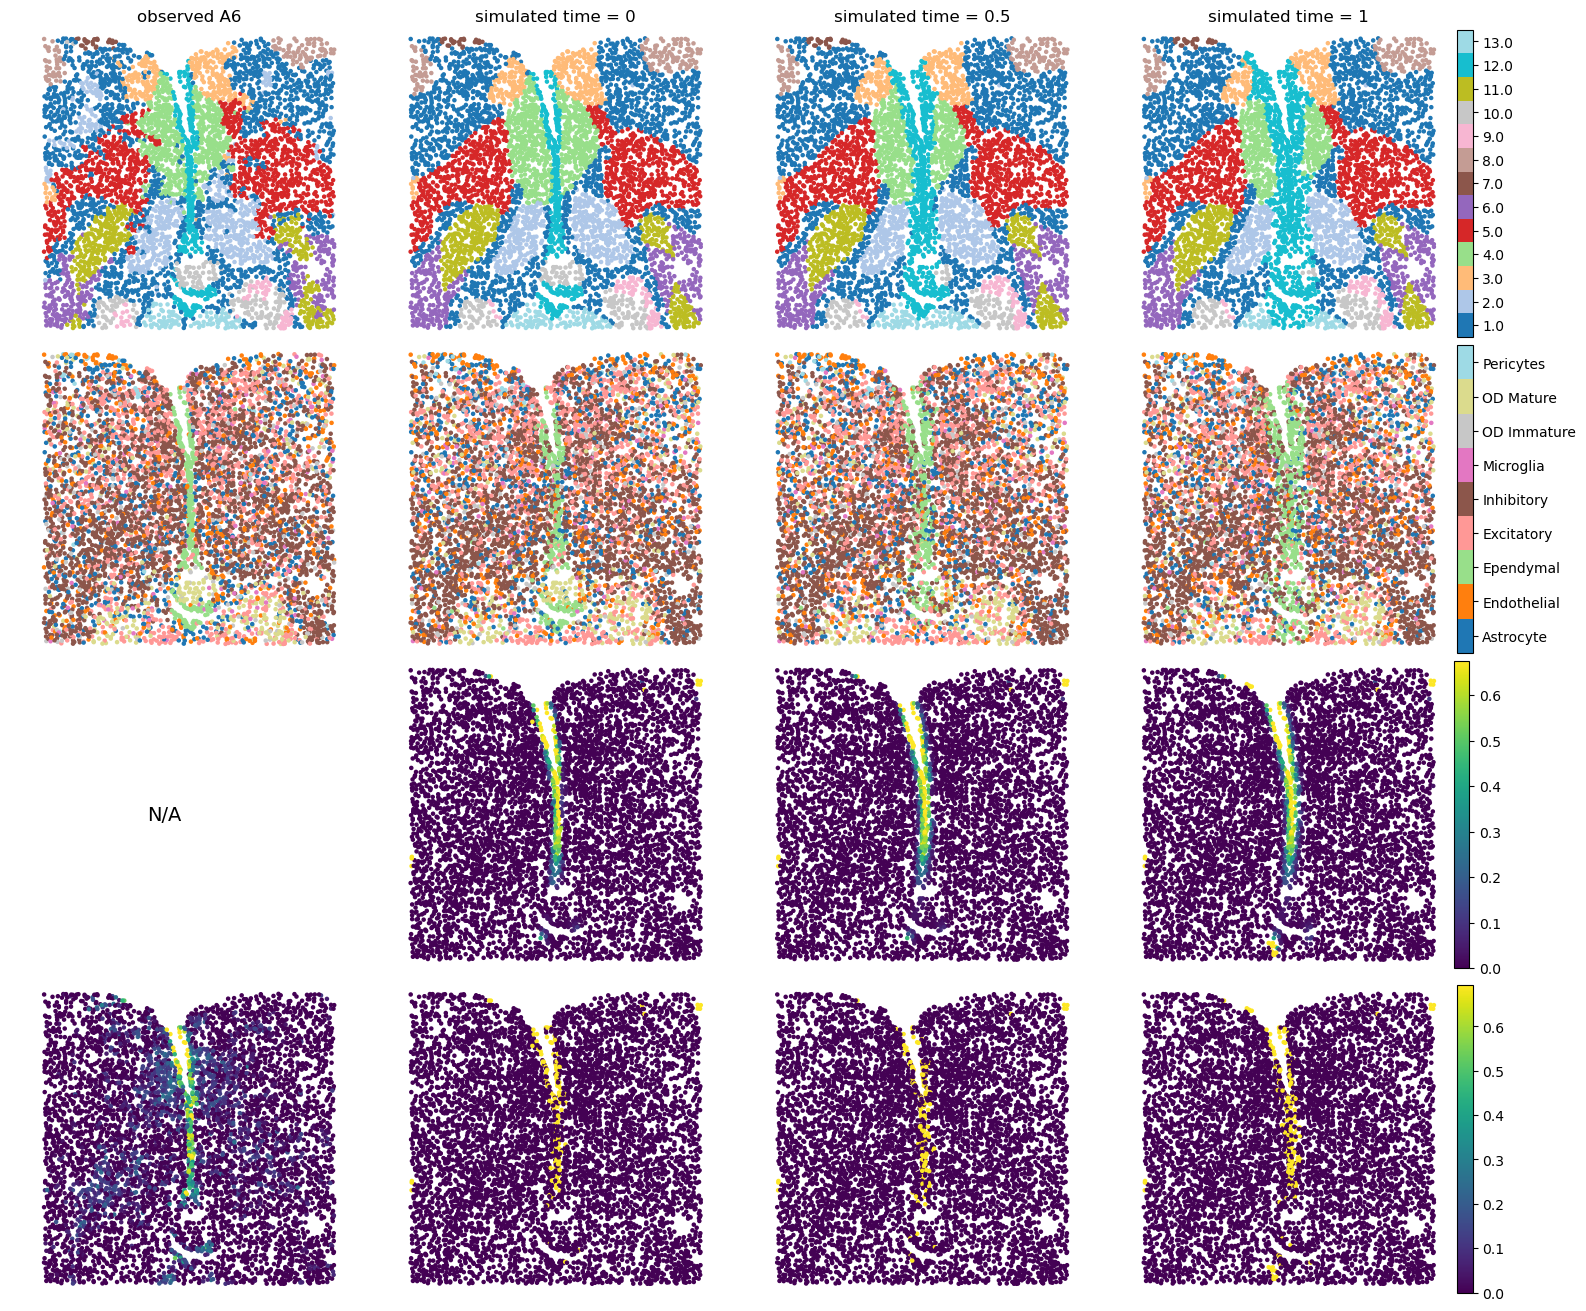

In [7]:
# ---------- summary and observed-versus-simulated figure ----------
t0_region_area = {
    region: weights[
        simulated_regions_t0 == region
    ].sum()
    for region in region_levels
}
t0_celltype_area = weights[
    simulated_celltypes_t0 == EXPECTED_CELLTYPE
].sum()

summary_rows = []

for h, t in enumerate(TIMES):
    active_mask = regions_by_time[h] == ACTIVE_REGION
    collision_mask = (
        regions_by_time[h] == COLLISION_REGION
    )
    expected_mask = (
        celltypes_by_time[h] == EXPECTED_CELLTYPE
    )

    summary_rows.append({
        "time": float(t),
        "changed_region_count_vs_sim_t0": int(
            np.sum(
                regions_by_time[h]
                != simulated_regions_t0
            )
        ),
        "changed_celltype_count_vs_sim_t0": int(
            np.sum(
                celltypes_by_time[h]
                != simulated_celltypes_t0
            )
        ),
        "active_region_area_ratio_vs_sim_t0": float(
            weights[active_mask].sum()
            / t0_region_area[ACTIVE_REGION]
        ),
        "collision_region_area_ratio_vs_sim_t0": float(
            weights[collision_mask].sum()
            / t0_region_area[COLLISION_REGION]
        ),
        f"{EXPECTED_CELLTYPE}_area_ratio_vs_sim_t0": float(
            weights[expected_mask].sum()
            / max(t0_celltype_area, 1e-12)
        ),
        f"{EXPECTED_CELLTYPE}_proportion_in_active_region": float(
            expected_mask[active_mask].mean()
        ),
        f"{PLOT_GENE}_expected_mean_in_active_region": float(
            gene_mu_by_time[h][active_mask].mean()
        ),
    })

summary = pd.DataFrame(summary_rows)
display(summary.round(4))


# Observed Nnat counts.
if "counts" in a6.layers:
    real_count_matrix = a6.layers["counts"]
else:
    real_count_matrix = a6.X

if hasattr(real_count_matrix, "toarray"):
    real_gene = np.asarray(
        real_count_matrix[:, gene_index].toarray()
    ).ravel()
else:
    real_gene = np.asarray(
        real_count_matrix[:, gene_index]
    ).ravel()

real_gene = np.log1p(real_gene)

region_plot_levels = sorted_labels(
    set(real_regions) | set(region_levels)
)
celltype_plot_levels = sorted_labels(
    set(real_celltypes) | set(celltype_names)
)

region_cmap = ListedColormap(
    plt.cm.tab20(
        np.linspace(0, 1, len(region_plot_levels))
    )
)
celltype_cmap = ListedColormap(
    plt.cm.tab20(
        np.linspace(0, 1, len(celltype_plot_levels))
    )
)

expected_gene = [
    np.log1p(mu)
    for mu in gene_mu_by_time
]
sampled_gene = [
    np.log1p(counts[:, gene_index])
    for counts in counts_by_time
]

expected_vmax = np.percentile(
    np.concatenate(expected_gene),
    99,
)
expression_vmax = np.percentile(
    np.concatenate([real_gene] + sampled_gene),
    99,
)

x_padding = 0.03 * np.ptp(xy[:, 0])
y_padding = 0.03 * np.ptp(xy[:, 1])
x_limits = (
    xy[:, 0].min() - x_padding,
    xy[:, 0].max() + x_padding,
)
y_limits = (
    xy[:, 1].max() + y_padding,
    xy[:, 1].min() - y_padding,
)

fig, axes = plt.subplots(
    4,
    len(TIMES) + 1,
    figsize=(16, 13),
    constrained_layout=True,
)

# ----- observed column -----
observed_region_code = pd.Categorical(
    real_regions,
    categories=region_plot_levels,
).codes
observed_celltype_code = pd.Categorical(
    real_celltypes,
    categories=celltype_plot_levels,
).codes

region_scatter = axes[0, 0].scatter(
    xy[:, 0],
    xy[:, 1],
    c=observed_region_code,
    s=5,
    cmap=region_cmap,
    vmin=-0.5,
    vmax=len(region_plot_levels) - 0.5,
)
celltype_scatter = axes[1, 0].scatter(
    xy[:, 0],
    xy[:, 1],
    c=observed_celltype_code,
    s=5,
    cmap=celltype_cmap,
    vmin=-0.5,
    vmax=len(celltype_plot_levels) - 0.5,
)

axes[2, 0].text(
    0.5,
    0.5,
    "N/A",
    ha="center",
    va="center",
    fontsize=14,
    transform=axes[2, 0].transAxes,
)

expression_scatter = axes[3, 0].scatter(
    xy[:, 0],
    xy[:, 1],
    c=real_gene,
    s=5,
    cmap="viridis",
    vmin=0,
    vmax=expression_vmax,
)

axes[0, 0].set_title("observed A6")

# ----- simulated columns -----
for column, (t, regions_t, celltypes_t) in enumerate(
    zip(
        TIMES,
        regions_by_time,
        celltypes_by_time,
    ),
    start=1,
):
    time_index = column - 1

    region_code = pd.Categorical(
        regions_t,
        categories=region_plot_levels,
    ).codes
    celltype_code = pd.Categorical(
        celltypes_t,
        categories=celltype_plot_levels,
    ).codes

    axes[0, column].scatter(
        xy[:, 0],
        xy[:, 1],
        c=region_code,
        s=5,
        cmap=region_cmap,
        vmin=-0.5,
        vmax=len(region_plot_levels) - 0.5,
    )
    axes[1, column].scatter(
        xy[:, 0],
        xy[:, 1],
        c=celltype_code,
        s=5,
        cmap=celltype_cmap,
        vmin=-0.5,
        vmax=len(celltype_plot_levels) - 0.5,
    )
    expected_scatter = axes[2, column].scatter(
        xy[:, 0],
        xy[:, 1],
        c=expected_gene[time_index],
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=expected_vmax,
    )
    axes[3, column].scatter(
        xy[:, 0],
        xy[:, 1],
        c=sampled_gene[time_index],
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=expression_vmax,
    )

    axes[0, column].set_title(
        f"simulated time = {t:g}"
    )

for axis in axes.ravel():
    axis.set_aspect("equal")
    axis.set_xlim(x_limits)
    axis.set_ylim(y_limits)
    axis.axis("off")

axes[0, 0].set_ylabel("Region", fontsize=12)
axes[1, 0].set_ylabel("Cell type", fontsize=12)
axes[2, 0].set_ylabel(
    f"log1p(E[{PLOT_GENE}])",
    fontsize=12,
)
axes[3, 0].set_ylabel(
    f"log1p({PLOT_GENE} expression)",
    fontsize=12,
)

region_colorbar = fig.colorbar(
    region_scatter,
    ax=axes[0, :],
    fraction=0.018,
    pad=0.01,
    ticks=np.arange(len(region_plot_levels)),
)
region_colorbar.ax.set_yticklabels(
    region_plot_levels
)

celltype_colorbar = fig.colorbar(
    celltype_scatter,
    ax=axes[1, :],
    fraction=0.018,
    pad=0.01,
    ticks=np.arange(len(celltype_plot_levels)),
)
celltype_colorbar.ax.set_yticklabels(
    celltype_plot_levels
)

fig.colorbar(
    expected_scatter,
    ax=axes[2, 1:],
    fraction=0.018,
    pad=0.01,
)
fig.colorbar(
    expression_scatter,
    ax=axes[3, :],
    fraction=0.018,
    pad=0.01,
)

plt.savefig(
    OUT_DIR / "A6_v6_observed_and_simulated_maps.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

In [8]:
# ---------- save simulated trajectory ----------
snapshots = {}

for h, t in enumerate(TIMES):
    obs = a6.obs.copy()

    obs["time"] = float(t)
    obs["real_region"] = real_regions
    obs["real_celltype"] = real_celltypes
    obs["simulated_region_t0"] = simulated_regions_t0
    obs["simulated_celltype_t0"] = simulated_celltypes_t0

    obs["simulated_region"] = regions_by_time[h]
    obs["simulated_celltype"] = celltypes_by_time[h]

    count_matrix = csr_matrix(
        counts_by_time[h]
    )

    snapshot = ad.AnnData(
        X=count_matrix,
        obs=obs,
        var=a6.var.copy(),
    )
    snapshot.layers["counts"] = (
        count_matrix.copy()
    )
    snapshot.obsm["spatial_3d"] = (
        coords_3d.copy()
    )
    snapshot.obsm[
        "celltype_template_relative_coordinates"
    ] = relative_coordinates_by_time[h].astype(
        np.float32
    )
    snapshot.obsm["pred_celltype_proba"] = (
        probabilities_by_time[h].astype(
            np.float32
        )
    )
    snapshot.uns["pred_celltype_names"] = (
        celltype_names.astype(str)
    )

    snapshots[f"t{t:g}"] = snapshot

synthetic = ad.concat(
    snapshots,
    label="timepoint",
    index_unique="-",
)

synthetic.write_h5ad(
    OUT_DIR / "A6_domain_timecourse_v6.h5ad"
)
summary.to_csv(
    OUT_DIR / "A6_v6_summary.csv",
    index=False,
)

print("Saved to:", OUT_DIR.resolve())

Saved to: /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/code_add_info/A6_domain_timecourse_v6
